<a href="https://colab.research.google.com/github/Lama-Alfaifi/fraud-detection-anomaly-ai/blob/main/03_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Modeling: Credit Card Fraud Detection**

**Objective:** Train and evaluate models on the cleaned data from `02_data_cleaning.ipynb`.

We compare two approaches:

1. **Isolation Forest** (Anomaly Detection, unsupervised): learns what *normal* looks like and flags outliers. This matches the idea of the project.
2. **HistGradientBoosting** (supervised, with class weights): used as a *benchmark* to see how much the labels help.

Since fraud is only ~0.58% of the data, **Accuracy is misleading** (a model that says "no fraud" always gets ~99.4%). We use **Precision, Recall, F1, and PR-AUC** instead.

**1. Imports**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, HistGradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve, f1_score)

**2. Load the cleaned data**

This is the file saved at the end of notebook 02. The data is loaded from Google Drive (`final_cleaned_fraud_data.csv`), so Drive must be mounted first.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
print('In current session:', [f for f in os.listdir('/content') if 'final' in f])
print('In Drive:', [f for f in os.listdir('/content/drive/MyDrive') if 'final' in f])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
In current session: []
In Drive: ['CNN final lab', 'final_cleaned_fraud_data.csv']


In [8]:
df = pd.read_csv('/content/drive/MyDrive/final_cleaned_fraud_data.csv')
print('Shape:', df.shape)
print('Fraud ratio: {:.3%}'.format(df['is_fraud'].mean()))
df.head()

Shape: (1296675, 77)
Fraud ratio: 0.579%


,amt,gender,lat,long,city_pop,is_fraud,hour,day of week,distance_km,age,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
0,4.97,1,36.0788,-81.1781,3495,0,0,1,78.773821,31,...,False,False,False,False,True,False,False,False,False,False
1,107.23,1,48.8878,-118.2105,149,0,0,1,30.216618,41,...,True,False,False,False,False,False,False,False,False,False
2,220.11,0,42.1808,-112.2620,4154,0,0,1,108.102912,57,...,False,False,False,False,False,False,False,False,False,False
3,45.00,0,46.2306,-112.1138,1939,0,0,1,95.685115,53,...,False,False,False,False,False,False,False,False,False,False
4,41.96,0,38.4207,-79.4629,99,0,0,1,77.702395,33,...,False,False,False,False,False,True,False,False,False,False


**3. Prepare features and split**

* `is_fraud` is the target, everything else is a feature.
* One-hot columns (`state_*`, `category_*`) may be saved as True/False, so we convert everything to numbers.
* **Stratified split** keeps the same fraud ratio in train and test.
* The scaler is fitted on the **train set only** to avoid data leakage.

In [9]:
X = df.drop(columns=['is_fraud']).astype(float)
y = df['is_fraud'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('Train:', X_train.shape, '| Fraud: {:.3%}'.format(y_train.mean()))
print('Test :', X_test.shape,  '| Fraud: {:.3%}'.format(y_test.mean()))

Train: (1037340, 76) | Fraud: 0.579%
Test : (259335, 76) | Fraud: 0.579%


**4. Model 1: Isolation Forest (Anomaly Detection)**

The model isolates points with random splits: outliers are isolated faster, so they get a more "anomalous" score.

* `contamination` = expected fraud ratio (~0.58%), taken from the training labels.
* The model is trained **without using the labels** during fitting. The labels are used only to set `contamination` and to evaluate the results.

In [10]:
contamination = float(y_train.mean())

iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    max_samples=256,
    n_jobs=-1,
    random_state=42)
iso.fit(X_train_s)

# predict(): -1 = anomaly, 1 = normal  ->  convert to 1 = fraud, 0 = normal
iso_pred = (iso.predict(X_test_s) == -1).astype(int)

# higher score = more anomalous
iso_score = -iso.score_samples(X_test_s)

print(classification_report(y_test, iso_pred, target_names=['Normal', 'Fraud'], digits=3))
print('ROC-AUC:', round(roc_auc_score(y_test, iso_score), 4))
print('PR-AUC :', round(average_precision_score(y_test, iso_score), 4))

              precision    recall  f1-score   support

      Normal      0.995     0.995     0.995    257834
       Fraud      0.128     0.125     0.126      1501

    accuracy                          0.990    259335
   macro avg      0.561     0.560     0.561    259335
weighted avg      0.990     0.990     0.990    259335

ROC-AUC: 0.7919
PR-AUC : 0.0662


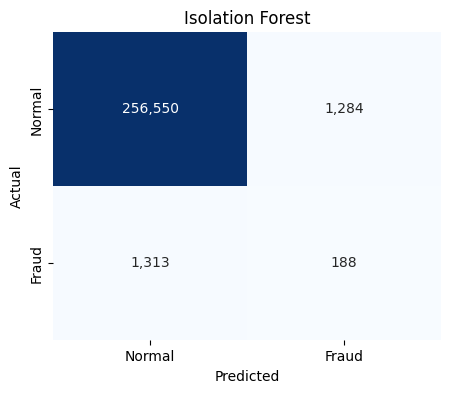

In [11]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

plot_cm(y_test, iso_pred, 'Isolation Forest')

**5. Model 2: HistGradientBoosting (supervised benchmark)**

This model uses the labels while training. `class_weight='balanced'` makes mistakes on the rare fraud class cost more.

              precision    recall  f1-score   support

      Normal      1.000     0.988     0.994    257834
       Fraud      0.321     0.974     0.482      1501

    accuracy                          0.988    259335
   macro avg      0.660     0.981     0.738    259335
weighted avg      0.996     0.988     0.991    259335

ROC-AUC: 0.998
PR-AUC : 0.9255


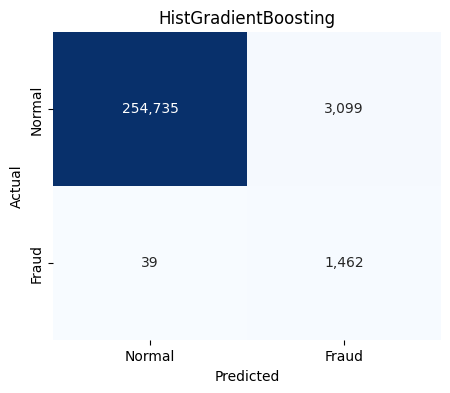

In [12]:
gb = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42)
gb.fit(X_train, y_train)

gb_proba = gb.predict_proba(X_test)[:, 1]
gb_pred  = (gb_proba >= 0.5).astype(int)

print(classification_report(y_test, gb_pred, target_names=['Normal', 'Fraud'], digits=3))
print('ROC-AUC:', round(roc_auc_score(y_test, gb_proba), 4))
print('PR-AUC :', round(average_precision_score(y_test, gb_proba), 4))

plot_cm(y_test, gb_pred, 'HistGradientBoosting')

**6. Threshold tuning**

The default threshold (0.5) is rarely the best choice for rare events.
We pick the threshold that gives the best F1 on the precision-recall curve.

> Tip: in a real bank, missing a fraud (False Negative) usually costs more than flagging a normal transaction (False Positive), so you may prefer a threshold with higher recall.

Best threshold: 0.974 | Precision: 0.930 | Recall: 0.824 | F1: 0.874


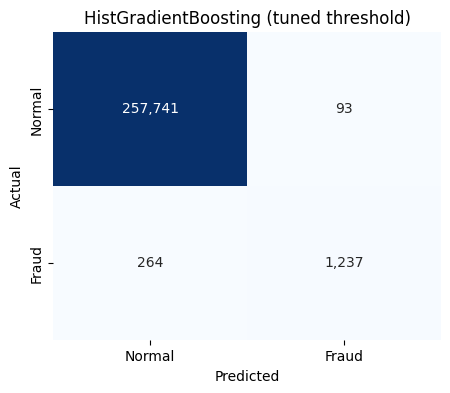

In [13]:
prec, rec, thr = precision_recall_curve(y_test, gb_proba)
f1 = 2 * prec * rec / (prec + rec + 1e-12)
best = np.argmax(f1[:-1])
best_thr = thr[best]
print('Best threshold: {:.3f} | Precision: {:.3f} | Recall: {:.3f} | F1: {:.3f}'.format(
    best_thr, prec[best], rec[best], f1[best]))

gb_pred_tuned = (gb_proba >= best_thr).astype(int)
plot_cm(y_test, gb_pred_tuned, 'HistGradientBoosting (tuned threshold)')

**7. Compare the models**

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


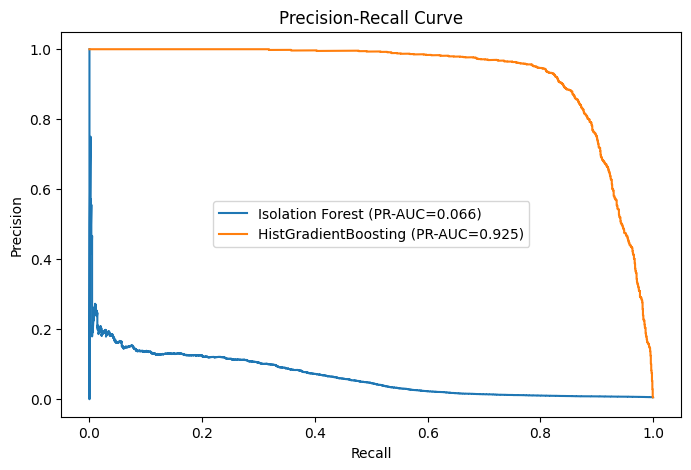

,Model,Precision,Recall,F1,PR-AUC
0,Isolation Forest,0.128,0.125,0.126,0.066
1,HistGradientBoosting,0.321,0.974,0.482,0.925
2,HistGradientBoosting (tuned),0.930,0.824,0.874,0.925


In [14]:
iso_prec, iso_rec, _ = precision_recall_curve(y_test, iso_score)

plt.figure(figsize=(8, 5))
plt.plot(iso_rec, iso_prec, label='Isolation Forest (PR-AUC={:.3f})'.format(average_precision_score(y_test, iso_score)))
plt.plot(rec, prec, label='HistGradientBoosting (PR-AUC={:.3f})'.format(average_precision_score(y_test, gb_proba)))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

results = pd.DataFrame({
    'Model': ['Isolation Forest', 'HistGradientBoosting', 'HistGradientBoosting (tuned)'],
    'Precision': [(iso_pred & y_test).sum() / max(iso_pred.sum(), 1),
                  (gb_pred & y_test).sum() / max(gb_pred.sum(), 1),
                  (gb_pred_tuned & y_test).sum() / max(gb_pred_tuned.sum(), 1)],
    'Recall': [(iso_pred & y_test).sum() / y_test.sum(),
               (gb_pred & y_test).sum() / y_test.sum(),
               (gb_pred_tuned & y_test).sum() / y_test.sum()],
    'F1': [f1_score(y_test, iso_pred), f1_score(y_test, gb_pred), f1_score(y_test, gb_pred_tuned)],
    'PR-AUC': [average_precision_score(y_test, iso_score),
               average_precision_score(y_test, gb_proba),
               average_precision_score(y_test, gb_proba)],
}).round(3)
results

**8. Save the best model**

In [15]:
import joblib
joblib.dump({'model': gb, 'threshold': best_thr}, 'fraud_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print('Saved: fraud_model.joblib, scaler.joblib')

Saved: fraud_model.joblib, scaler.joblib


In [17]:
!cp fraud_model.joblib scaler.joblib /content/drive/MyDrive/

In [18]:
import os
print([f for f in os.listdir('/content/drive/MyDrive') if f.endswith('.joblib')])

['fraud_model.joblib', 'scaler.joblib']


## **Conclusion**

* **Isolation Forest** (unsupervised) performed poorly (PR-AUC 0.066). Fraudulent transactions are not strong statistical outliers in this dataset, as we also saw in notebook 02 where `distance_km` alone did not separate fraud.
* **HistGradientBoosting** (supervised) performed far better (PR-AUC 0.925, ROC-AUC 0.998). With the default threshold it catches 97% of fraud but with low precision (0.32). After threshold tuning (0.974) it reached **Precision 0.93, Recall 0.82, F1 0.87**.
* Accuracy is not a useful metric here because only 0.58% of transactions are fraud.
* **Limitations:** the threshold was selected on the same test set used for evaluation, so the tuned numbers may be slightly optimistic, and the same customers may appear in both train and test.